# LendingClub discrete-time hazard model project
# File: data/raw/accepted_2007_to_2018Q4.csv.gz
#
# Workflow:
# 1. Load and clean data
# 2. Define event and censoring
# 3. Create duration
# 4. Expand to loan-month panel
# 5. Train/valid/test split
# 6. Logistic hazard model
# 7. Random forest comparison
# 8. Cumulative PD
# 9. Expected loss / reserve / pricing summaries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [ ]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

accepted_path = RAW_DIR / "lendingclub" /"accepted_2007_to_2018Q4.csv.gz"

# Runtime controls
USE_SAMPLE = True          # set to False if you want the full dataset
SAMPLE_SIZE = 90000        # increase later if your machine can handle it
RANDOM_STATE = 42

In [3]:
df_raw = pd.read_csv(
    accepted_path,
    low_memory=False,
    compression="gzip"
)

print("Raw shape:", df_raw.shape)
print("First 20 columns:", df_raw.columns.tolist()[:20])

Raw shape: (2260701, 151)
First 20 columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']


In [4]:
key_columns = [
    "id",
    "issue_d",
    "loan_status",
    "term",
    "loan_amnt",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_range_low",
    "fico_range_high",
    "earliest_cr_line",
    "last_pymnt_d",
    "last_credit_pull_d",
]

missing_cols = [c for c in key_columns if c not in df_raw.columns]
print("Missing columns:", missing_cols)

Missing columns: []


In [5]:
cols = [c for c in key_columns if c in df_raw.columns]
df = df_raw[cols].copy()

print("Working shape:", df.shape)
df.head()

Working shape: (2260701, 27)


,id,issue_d,loan_status,term,loan_amnt,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_range_low,fico_range_high,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,68407277,Dec-2015,Fully Paid,36 months,3600.0,123.03,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,1.0,0.0,675.0,679.0,Aug-2003,Jan-2019,Mar-2019
1,68355089,Dec-2015,Fully Paid,36 months,24700.0,820.28,10+ years,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,4.0,0.0,715.0,719.0,Dec-1999,Jun-2016,Mar-2019
2,68341763,Dec-2015,Fully Paid,60 months,20000.0,432.66,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,5.0,0.0,695.0,699.0,Aug-2000,Jun-2017,Mar-2019
3,66310712,Dec-2015,Current,60 months,35000.0,829.90,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,NJ,17.06,0.0,0.0,13.0,0.0,7802.0,11.6,17.0,1.0,0.0,785.0,789.0,Sep-2008,Feb-2019,Mar-2019
4,68476807,Dec-2015,Fully Paid,60 months,10400.0,289.91,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,3.0,12.0,0.0,21929.0,64.5,35.0,6.0,0.0,695.0,699.0,Jun-1998,Jul-2016,Mar-2018


In [6]:
if USE_SAMPLE:
    df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).copy()

print("Shape after optional sampling:", df.shape)

Shape after optional sampling: (2260701, 27)


In [7]:
date_cols = ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], format="%b-%Y", errors="coerce")

df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

df["term_num"] = (
    df["term"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df["credit_history_years"] = (
    (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25
)

df[["issue_d", "loan_status", "term", "term_num", "fico_avg", "credit_history_years"]].head()

,issue_d,loan_status,term,term_num,fico_avg,credit_history_years
0,2015-12-01,Fully Paid,36 months,36.0,677.0,12.334018
1,2015-12-01,Fully Paid,36 months,36.0,717.0,16.000000
2,2015-12-01,Fully Paid,60 months,60.0,697.0,15.331964
3,2015-12-01,Current,60 months,60.0,787.0,7.247091
4,2015-12-01,Fully Paid,60 months,60.0,697.0,17.500342


In [8]:
status_counts = df["loan_status"].value_counts(dropna=False)
status_counts

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [9]:
# Basic event definition:
# event = 1 for default-like outcomes
# event = 0 otherwise

default_statuses = {
    "Charged Off",
    "Default",
}

df["event"] = df["loan_status"].isin(default_statuses).astype(int)

# Use last payment date if available; otherwise use last credit pull date
df["end_date"] = df["last_pymnt_d"]
mask_missing_end = df["end_date"].isna()
df.loc[mask_missing_end, "end_date"] = df.loc[mask_missing_end, "last_credit_pull_d"]

df[["loan_status", "event", "issue_d", "last_pymnt_d", "last_credit_pull_d", "end_date"]].head()

,loan_status,event,issue_d,last_pymnt_d,last_credit_pull_d,end_date
0,Fully Paid,0,2015-12-01,2019-01-01,2019-03-01,2019-01-01
1,Fully Paid,0,2015-12-01,2016-06-01,2019-03-01,2016-06-01
2,Fully Paid,0,2015-12-01,2017-06-01,2019-03-01,2017-06-01
3,Current,0,2015-12-01,2019-02-01,2019-03-01,2019-02-01
4,Fully Paid,0,2015-12-01,2016-07-01,2018-03-01,2016-07-01


In [10]:
def month_diff(start, end):
    return (end.dt.year - start.dt.year) * 12 + (end.dt.month - start.dt.month)

df = df[df["issue_d"].notna()].copy()
df = df[df["end_date"].notna()].copy()

df["duration_months"] = month_diff(df["issue_d"], df["end_date"])
df["duration_months"] = df["duration_months"].clip(lower=1)

print(df.shape)
df[["id", "issue_d", "end_date", "duration_months", "event"]].head()

(2260668, 33)


,id,issue_d,end_date,duration_months,event
0,68407277,2015-12-01,2019-01-01,37,0
1,68355089,2015-12-01,2016-06-01,6,0
2,68341763,2015-12-01,2017-06-01,18,0
3,66310712,2015-12-01,2019-02-01,38,0
4,68476807,2015-12-01,2016-07-01,7,0


In [11]:
df = df[df["term_num"].isin([36, 60])].copy()
df = df[df["duration_months"] >= 1].copy()
df = df[df["fico_avg"].notna()].copy()

print("After cleaning/filtering:", df.shape)

After cleaning/filtering: (2260668, 33)


In [12]:
print("Event rate:")
print(df["event"].value_counts(normalize=True))

print("\nLoan status counts:")
print(df["loan_status"].value_counts(dropna=False).head(20))

print("\nDuration summary:")
print(df["duration_months"].describe())

Event rate:
event
0    0.881186
1    0.118814
Name: proportion, dtype: float64

Loan status counts:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Duration summary:
count    2.260668e+06
mean     1.955664e+01
std      1.238613e+01
min      1.000000e+00
25%      9.000000e+00
50%      1.700000e+01
75%      2.900000e+01
max      1.330000e+02
Name: duration_months, dtype: float64


In [13]:
loan_level_path = PROCESSED_DIR / "loan_level_survival_base.csv"
df.to_csv(loan_level_path, index=False)
print(f"Saved loan-level base to: {loan_level_path}")

Saved loan-level base to: data/processed/loan_level_survival_base.csv


In [ ]:
static_cols = [
    "loan_amnt",
    "term_num",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
]

def expand_loan(row):
    n = int(row["duration_months"])
    event = int(row["event"])

    out = pd.DataFrame({
        "id": row["id"],
        "issue_d": row["issue_d"],
        "month_on_book": np.arange(1, n + 1),
        "duration_months": row["duration_months"],
        "event": row["event"],
    })

    out["hazard_target"] = 0
    if event == 1:
        out.loc[out["month_on_book"] == n, "hazard_target"] = 1

    for col in static_cols:
        out[col] = row[col]

    return out

: 

In [ ]:
panel_parts = []
for _, row in df.iterrows():
    panel_parts.append(expand_loan(row))

panel = pd.concat(panel_parts, ignore_index=True)

print("Panel shape:", panel.shape)
panel.head()

In [ ]:
panel["mob_str"] = panel["month_on_book"].astype(str)
panel["fico_x_mob"] = panel["fico_avg"] * panel["month_on_book"]
panel["term_x_mob"] = panel["term_num"] * panel["month_on_book"]
panel["dti_x_mob"] = panel["dti"] * panel["month_on_book"]

In [ ]:
# Cleaner time specification
panel["mob_6bin"] = pd.cut(
    panel["month_on_book"],
    bins=[0, 6, 12, 18, 24, 36, 60, 120],
    labels=["1_6", "7_12", "13_18", "19_24", "25_36", "37_60", "61_plus"]
)

panel["month_on_book_sq"] = panel["month_on_book"] ** 2

# optional vintage variable
panel["issue_year"] = panel["issue_d"].dt.year.astype(str)

In [ ]:
panel_path = PROCESSED_DIR / "loan_month_panel.csv"
panel.to_csv(panel_path, index=False)
print(f"Saved panel to: {panel_path}")

Saved panel to: data/processed/loan_month_panel.csv


In [ ]:
train_panel = panel[panel["issue_d"] < "2015-01-01"].copy()
valid_panel = panel[(panel["issue_d"] >= "2015-01-01") & (panel["issue_d"] < "2016-01-01")].copy()
test_panel  = panel[panel["issue_d"] >= "2016-01-01"].copy()

print("Train shape:", train_panel.shape)
print("Valid shape:", valid_panel.shape)
print("Test shape :", test_panel.shape)

Train shape: (517939, 34)
Valid shape: (218609, 34)
Test shape : (242267, 34)


In [ ]:
target = "hazard_target"

numeric_features = [
    "loan_amnt",
    "term_num",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
    "fico_x_mob",
    "term_x_mob",
    "dti_x_mob",
]

categorical_features = [
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "mob_str",      # full month dummy
    "mob_6bin",     # can keep this too
]

In [ ]:
X_train = train_panel[numeric_features + categorical_features]
y_train = train_panel[target]

X_valid = valid_panel[numeric_features + categorical_features]
y_valid = valid_panel[target]

X_test = test_panel[numeric_features + categorical_features]
y_test = test_panel[target]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(517939, 26) (517939,)
(218609, 26) (218609,)
(242267, 26) (242267,)


In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [ ]:
hazard_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

hazard_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [ ]:
valid_pred_hazard = hazard_model.predict_proba(X_valid)[:, 1]
test_pred_hazard = hazard_model.predict_proba(X_test)[:, 1]

hazard_results = {
    "valid_roc_auc": roc_auc_score(y_valid, valid_pred_hazard),
    "valid_pr_auc": average_precision_score(y_valid, valid_pred_hazard),
    "test_roc_auc": roc_auc_score(y_test, test_pred_hazard),
    "test_pr_auc": average_precision_score(y_test, test_pred_hazard),
}

hazard_results

{'valid_roc_auc': 0.6734851733235421,
 'valid_pr_auc': 0.014246459661086397,
 'test_roc_auc': 0.6795994085731828,
 'test_pr_auc': 0.009149020593654132}

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
rf_base = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )),
])

rf_calibrated = CalibratedClassifierCV(
    estimator=rf_base,
    method="sigmoid",
    cv=3
)

rf_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [ ]:
valid_pred_rf = rf_calibrated.predict_proba(X_valid)[:, 1]
test_pred_rf = rf_calibrated.predict_proba(X_test)[:, 1]

rf_results = {
    "valid_roc_auc": roc_auc_score(y_valid, valid_pred_rf),
    "valid_pr_auc": average_precision_score(y_valid, valid_pred_rf),
    "test_roc_auc": roc_auc_score(y_test, test_pred_rf),
    "test_pr_auc": average_precision_score(y_test, test_pred_rf),
}

rf_results

{'valid_roc_auc': 0.650350692041953,
 'valid_pr_auc': 0.013067735674963932,
 'test_roc_auc': 0.66656009137195,
 'test_pr_auc': 0.008563485235153252}

In [ ]:
results_df = pd.DataFrame([
    {
        "model": "logistic_hazard",
        **hazard_results
    },
    {
        "model": "random_forest",
        **rf_results
    }
])

results_df

,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc
0,logistic_hazard,0.673485,0.014246,0.679599,0.009149
1,random_forest,0.650351,0.013068,0.666560,0.008563


In [ ]:
test_scored = test_panel.copy()
test_scored["pred_hazard_logit"] = test_pred_hazard
test_scored["pred_hazard_rf"] = test_pred_rf

test_scored = test_scored.sort_values(["id", "month_on_book"]).copy()
test_scored.head()

,id,issue_d,month_on_book,duration_months,event,hazard_target,loan_amnt,term_num,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years,mob_str,fico_x_mob,term_x_mob,dti_x_mob,mob_6bin,month_on_book_sq,issue_year,pred_hazard_logit,pred_hazard_rf
214997,100001365,2017-03-01,1,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,1,662.0,36.0,25.3,1_6,1,2017,0.002018,0.002531
214998,100001365,2017-03-01,2,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,2,1324.0,72.0,50.6,1_6,4,2017,0.002836,0.003090
214999,100001365,2017-03-01,3,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,3,1986.0,108.0,75.9,1_6,9,2017,0.003856,0.004177
215000,100001365,2017-03-01,4,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,4,2648.0,144.0,101.2,1_6,16,2017,0.004185,0.003723
215001,100001365,2017-03-01,5,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,5,3310.0,180.0,126.5,1_6,25,2017,0.004603,0.003410


In [ ]:
test_scored["survival_prob_logit"] = test_scored.groupby("id")["pred_hazard_logit"].transform(
    lambda x: (1 - x).cumprod()
)
test_scored["cum_pd_logit"] = 1 - test_scored["survival_prob_logit"]

test_scored["survival_prob_rf"] = test_scored.groupby("id")["pred_hazard_rf"].transform(
    lambda x: (1 - x).cumprod()
)
test_scored["cum_pd_rf"] = 1 - test_scored["survival_prob_rf"]

test_scored[[
    "id", "month_on_book", "pred_hazard_logit", "cum_pd_logit",
    "pred_hazard_rf", "cum_pd_rf"
]].head(20)

,id,month_on_book,pred_hazard_logit,cum_pd_logit,pred_hazard_rf,cum_pd_rf
214997,100001365,1,0.002018,0.002018,0.002531,0.002531
214998,100001365,2,0.002836,0.004847,0.003090,0.005614
214999,100001365,3,0.003856,0.008685,0.004177,0.009767
215000,100001365,4,0.004185,0.012833,0.003723,0.013453
215001,100001365,5,0.004603,0.017377,0.003410,0.016817
215002,100001365,6,0.005281,0.022567,0.004457,0.021199
215003,100001365,7,0.007772,0.030163,0.005967,0.027039
215004,100001365,8,0.006811,0.036768,0.006484,0.033347
215005,100001365,9,0.007068,0.043576,0.006960,0.040076
215006,100001365,10,0.007575,0.050821,0.008106,0.047857


In [ ]:
pd_summary = (
    test_scored[test_scored["month_on_book"].isin([6, 12, 24, 36])]
    .groupby("month_on_book")
    .agg(
        avg_cum_pd_logit=("cum_pd_logit", "mean"),
        avg_cum_pd_rf=("cum_pd_rf", "mean"),
        loans=("id", "nunique"),
    )
    .reset_index()
)

pd_summary

,month_on_book,avg_cum_pd_logit,avg_cum_pd_rf,loans
0,6,0.020484,0.021934,16402
1,12,0.056629,0.056323,9504
2,24,0.134478,0.134557,1103


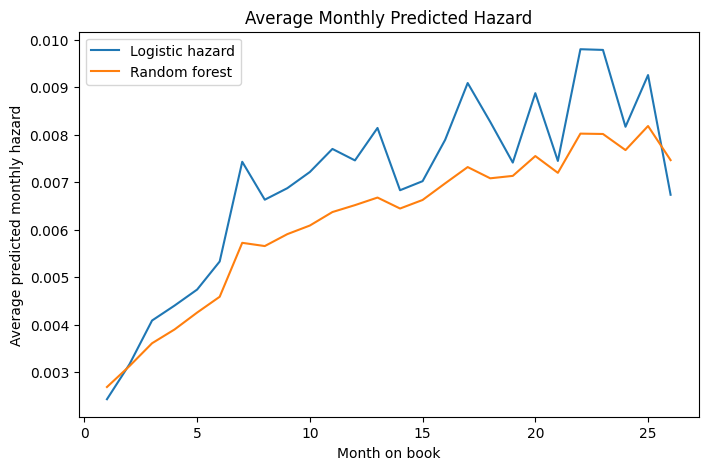

In [ ]:
plot_hazard = (
    test_scored.groupby("month_on_book")[["pred_hazard_logit", "pred_hazard_rf"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(plot_hazard["month_on_book"], plot_hazard["pred_hazard_logit"], label="Logistic hazard")
plt.plot(plot_hazard["month_on_book"], plot_hazard["pred_hazard_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Average predicted monthly hazard")
plt.title("Average Monthly Predicted Hazard")
plt.legend()
plt.show()

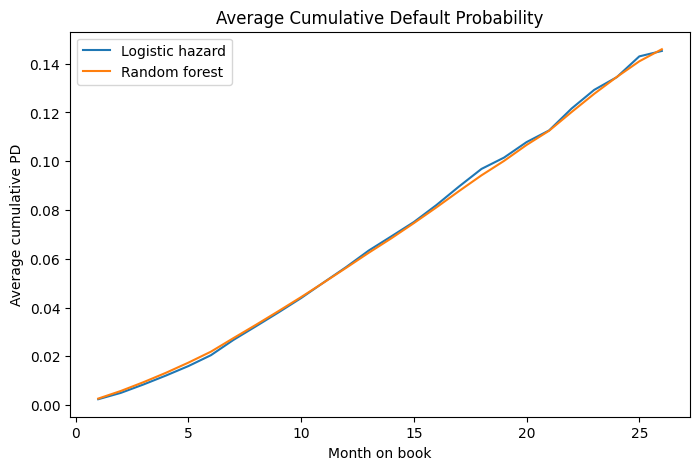

In [ ]:
plot_cum_pd = (
    test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(plot_cum_pd["month_on_book"], plot_cum_pd["cum_pd_logit"], label="Logistic hazard")
plt.plot(plot_cum_pd["month_on_book"], plot_cum_pd["cum_pd_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Average cumulative PD")
plt.title("Average Cumulative Default Probability")
plt.legend()
plt.show()

In [ ]:
loan_12m = test_scored[test_scored["month_on_book"] == 12].copy()

print("Loans with 12-month horizon rows:", loan_12m["id"].nunique())
loan_12m[["id", "cum_pd_logit", "cum_pd_rf"]].head()

Loans with 12-month horizon rows: 9504


,id,cum_pd_logit,cum_pd_rf
215008,100001365,0.066397,0.063470
539498,100001532,0.020857,0.037342
62778,100002096,0.060577,0.062477
86881,100003912,0.029064,0.047593
866480,100005538,0.055903,0.079091


In [ ]:
LGD = 0.60

loan_12m["ead_proxy"] = loan_12m["loan_amnt"]
loan_12m["expected_loss_12m_logit"] = loan_12m["cum_pd_logit"] * LGD * loan_12m["ead_proxy"]
loan_12m["expected_loss_12m_rf"] = loan_12m["cum_pd_rf"] * LGD * loan_12m["ead_proxy"]

loan_12m[[
    "id",
    "loan_amnt",
    "cum_pd_logit",
    "cum_pd_rf",
    "expected_loss_12m_logit",
    "expected_loss_12m_rf"
]].head()

,id,loan_amnt,cum_pd_logit,cum_pd_rf,expected_loss_12m_logit,expected_loss_12m_rf
215008,100001365,20000.0,0.066397,0.063470,796.761752,761.642829
539498,100001532,30000.0,0.020857,0.037342,375.424332,672.159660
62778,100002096,20000.0,0.060577,0.062477,726.918874,749.729448
86881,100003912,28500.0,0.029064,0.047593,497.002624,813.838191
866480,100005538,14400.0,0.055903,0.079091,483.005341,683.343063


In [ ]:
funding_cost = 0.04
profit_margin = 0.03

loan_12m["el_rate_12m_logit"] = loan_12m["expected_loss_12m_logit"] / loan_12m["loan_amnt"]
loan_12m["el_rate_12m_rf"] = loan_12m["expected_loss_12m_rf"] / loan_12m["loan_amnt"]

loan_12m["required_rate_logit"] = funding_cost + profit_margin + loan_12m["el_rate_12m_logit"]
loan_12m["required_rate_rf"] = funding_cost + profit_margin + loan_12m["el_rate_12m_rf"]

loan_12m[[
    "id",
    "required_rate_logit",
    "required_rate_rf"
]].head()

,id,required_rate_logit,required_rate_rf
215008,100001365,0.109838,0.108082
539498,100001532,0.082514,0.092405
62778,100002096,0.106346,0.107486
86881,100003912,0.087439,0.098556
866480,100005538,0.103542,0.117454


In [ ]:
loan_12m["risk_band_logit"] = pd.qcut(
    loan_12m["cum_pd_logit"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_logit = (
    loan_12m.groupby("risk_band_logit")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_logit", "mean"),
        total_expected_loss=("expected_loss_12m_logit", "sum"),
        avg_required_rate=("required_rate_logit", "mean"),
    )
    .reset_index()
)

reserve_summary_logit

,risk_band_logit,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,1901,0.020887,3.616288e+05,0.082532
1,Low,1901,0.035138,5.423714e+05,0.091083
2,Medium,1900,0.047684,7.668849e+05,0.098611
3,High,1901,0.064353,1.084680e+06,0.108612
4,Very High,1901,0.115078,2.392863e+06,0.139047


In [ ]:
loan_12m["risk_band_rf"] = pd.qcut(
    loan_12m["cum_pd_rf"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_rf = (
    loan_12m.groupby("risk_band_rf")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_rf", "mean"),
        total_expected_loss=("expected_loss_12m_rf", "sum"),
        avg_required_rate=("required_rate_rf", "mean"),
    )
    .reset_index()
)

reserve_summary_rf

,risk_band_rf,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,1901,0.035993,5.828608e+05,0.091596
1,Low,1901,0.044699,7.223600e+05,0.096820
2,Medium,1900,0.052556,8.712743e+05,0.101534
3,High,1901,0.062570,1.080326e+06,0.107542
4,Very High,1901,0.085796,1.710220e+06,0.121478


In [ ]:
test_scored_path = PROCESSED_DIR / "test_panel_scored.csv"
loan_12m_path = PROCESSED_DIR / "loan_level_12m_outputs.csv"
results_path = PROCESSED_DIR / "model_comparison_results.csv"

test_scored.to_csv(test_scored_path, index=False)
loan_12m.to_csv(loan_12m_path, index=False)
results_df.to_csv(results_path, index=False)

print(f"Saved scored panel to: {test_scored_path}")
print(f"Saved 12m loan outputs to: {loan_12m_path}")
print(f"Saved model comparison to: {results_path}")

Saved scored panel to: data/processed/test_panel_scored.csv
Saved 12m loan outputs to: data/processed/loan_level_12m_outputs.csv
Saved model comparison to: data/processed/model_comparison_results.csv


In [ ]:
print("Model comparison:")
display(results_df)

print("\n12-month cumulative PD summary:")
display(pd_summary)

print("\nReserve summary (logistic hazard):")
display(reserve_summary_logit)

Model comparison:


,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc
0,logistic_hazard,0.673485,0.014246,0.679599,0.009149
1,random_forest,0.650351,0.013068,0.666560,0.008563



12-month cumulative PD summary:


,month_on_book,avg_cum_pd_logit,avg_cum_pd_rf,loans
0,6,0.020484,0.021934,16402
1,12,0.056629,0.056323,9504
2,24,0.134478,0.134557,1103



Reserve summary (logistic hazard):


,risk_band_logit,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,1901,0.020887,3.616288e+05,0.082532
1,Low,1901,0.035138,5.423714e+05,0.091083
2,Medium,1900,0.047684,7.668849e+05,0.098611
3,High,1901,0.064353,1.084680e+06,0.108612
4,Very High,1901,0.115078,2.392863e+06,0.139047


In [ ]:
loan_12m["risk_band_rf"] = pd.qcut(
    loan_12m["cum_pd_rf"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_rf = (
    loan_12m.groupby("risk_band_rf")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_rf", "mean"),
        total_expected_loss=("expected_loss_12m_rf", "sum"),
        avg_required_rate=("required_rate_rf", "mean"),
    )
    .reset_index()
)

reserve_summary_rf

,risk_band_rf,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,1901,0.035993,5.828608e+05,0.091596
1,Low,1901,0.044699,7.223600e+05,0.096820
2,Medium,1900,0.052556,8.712743e+05,0.101534
3,High,1901,0.062570,1.080326e+06,0.107542
4,Very High,1901,0.085796,1.710220e+06,0.121478


# Looking at test

In [ ]:
test_loans = df[df["issue_d"] >= "2017-01-01"].copy()

loan_obs = test_loans[["id", "duration_months", "event"]].drop_duplicates().copy()

print(loan_obs.shape)
loan_obs.head()

(20781, 3)


,id,duration_months,event
2066630,125356772,10,0
477199,128490686,13,0
641990,109655666,14,0
507598,127049010,14,0
2129008,121746633,17,0


In [ ]:
max_mob = int(test_scored["month_on_book"].max())
months = np.arange(1, max_mob + 1)

n_loans = loan_obs["id"].nunique()

observed_curve = pd.DataFrame({"month_on_book": months})

observed_curve["observed_cum_pd"] = [
    ((loan_obs["event"] == 1) & (loan_obs["duration_months"] <= m)).sum() / n_loans
    for m in months
]

observed_curve.head(15)

,month_on_book,observed_cum_pd
0,1,0.001732
1,2,0.004283
2,3,0.007266
3,4,0.011693
4,5,0.015495
5,6,0.019200
6,7,0.023242
7,8,0.026659
8,9,0.030124
9,10,0.033396


In [ ]:
plot_cum_pd = (
    test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
    .mean()
    .reset_index()
)

In [ ]:
compare_curve = observed_curve.merge(
    plot_cum_pd,
    on="month_on_book",
    how="inner"
)

compare_curve.head()

,month_on_book,observed_cum_pd,cum_pd_logit,cum_pd_rf
0,1,0.001732,0.002430,0.002687
1,2,0.004283,0.005024,0.005805
2,3,0.007266,0.008448,0.009389
3,4,0.011693,0.012121,0.013248
4,5,0.015495,0.016022,0.017434


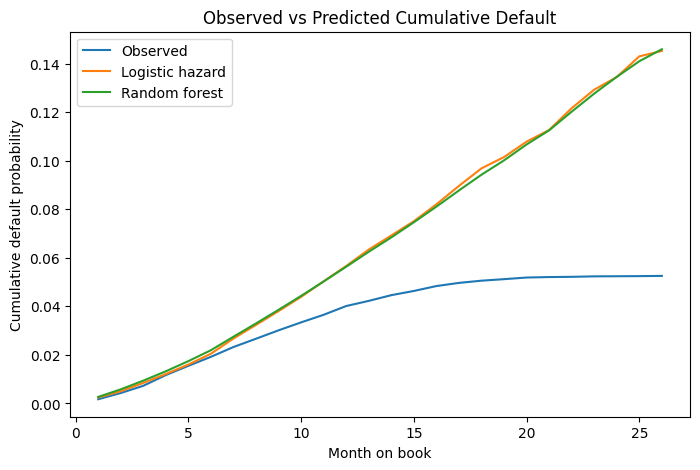

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(compare_curve["month_on_book"], compare_curve["observed_cum_pd"], label="Observed")
plt.plot(compare_curve["month_on_book"], compare_curve["cum_pd_logit"], label="Logistic hazard")
plt.plot(compare_curve["month_on_book"], compare_curve["cum_pd_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Cumulative default probability")
plt.title("Observed vs Predicted Cumulative Default")
plt.legend()
plt.show()

In [ ]:
milestones = [6, 12, 18, 24]

calibration_table = compare_curve[
    compare_curve["month_on_book"].isin(milestones)
].copy()

calibration_table["logit_error"] = (
    calibration_table["cum_pd_logit"] - calibration_table["observed_cum_pd"]
)

calibration_table["rf_error"] = (
    calibration_table["cum_pd_rf"] - calibration_table["observed_cum_pd"]
)

calibration_table

,month_on_book,observed_cum_pd,cum_pd_logit,cum_pd_rf,logit_error,rf_error
5,6,0.019200,0.020484,0.021934,0.001283,0.002734
11,12,0.040133,0.056629,0.056323,0.016496,0.016190
17,18,0.050575,0.096862,0.094236,0.046287,0.043661
23,24,0.052404,0.134478,0.134557,0.082075,0.082153


Loan-level test sample shape: (20781, 3)
                id  duration_months  event
2066630  125356772               10      0
477199   128490686               13      0
641990   109655666               14      0
507598   127049010               14      0
2129008  121746633               17      0

Kaplan-Meier curve:
    month_on_book  survival_prob  observed_cum_pd_km
0             0.0       1.000000            0.000000
1             1.0       0.998268            0.001732
2             2.0       0.995668            0.004332
3             3.0       0.992590            0.007410
4             4.0       0.987773            0.012227
5             5.0       0.983358            0.016642
6             6.0       0.978742            0.021258
7             7.0       0.973322            0.026678
8             8.0       0.968358            0.031642
9             9.0       0.962924            0.037076
10           10.0       0.957323            0.042677
11           11.0       0.951409            

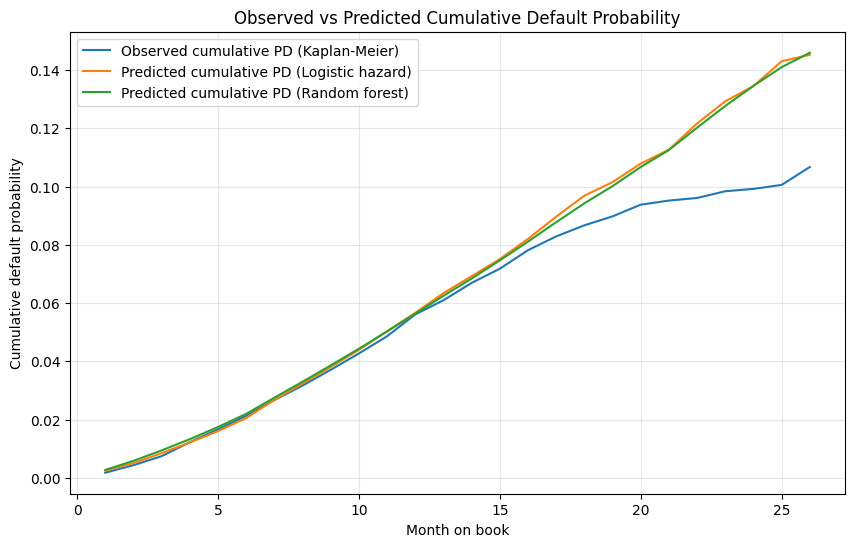


Calibration table:
    month_on_book  observed_cum_pd_km  cum_pd_logit  cum_pd_rf  logit_error  \
5               6            0.021258      0.020484   0.021934    -0.000775   
11             12            0.056099      0.056629   0.056323     0.000530   
17             18            0.086677      0.096862   0.094236     0.010185   
23             24            0.099196      0.134478   0.134557     0.035282   

    rf_error  
5   0.000676  
11  0.000224  
17  0.007559  
23  0.035361  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# =========================================================
# 1. Build loan-level TEST set for Kaplan-Meier
# =========================================================

# Make sure issue_d is datetime
df["issue_d"] = pd.to_datetime(df["issue_d"], errors="coerce")

# Match your test split
test_loans = df[df["issue_d"] >= "2017-01-01"].copy()

# Keep one row per loan with survival inputs
loan_obs = (
    test_loans[["id", "duration_months", "event"]]
    .drop_duplicates(subset=["id"])
    .copy()
)

# Clean types
loan_obs["duration_months"] = pd.to_numeric(loan_obs["duration_months"], errors="coerce")
loan_obs["event"] = pd.to_numeric(loan_obs["event"], errors="coerce")

# Drop bad rows if any
loan_obs = loan_obs.dropna(subset=["id", "duration_months", "event"]).copy()

# Optional: force valid ranges/types
loan_obs["duration_months"] = loan_obs["duration_months"].astype(int)
loan_obs["event"] = loan_obs["event"].astype(int)

print("Loan-level test sample shape:", loan_obs.shape)
print(loan_obs.head())


# =========================================================
# 2. Fit Kaplan-Meier on observed test-loan outcomes
# =========================================================

kmf = KaplanMeierFitter()

kmf.fit(
    durations=loan_obs["duration_months"],
    event_observed=loan_obs["event"],
    label="Kaplan-Meier survival"
)

# Convert survival curve to cumulative default curve
km_curve = kmf.survival_function_.reset_index()
km_curve.columns = ["month_on_book", "survival_prob"]
km_curve["observed_cum_pd_km"] = 1 - km_curve["survival_prob"]

print("\nKaplan-Meier curve:")
print(km_curve.head(15))


# =========================================================
# 3. Build average model-predicted cumulative PD curve
# =========================================================

plot_cum_pd = (
    test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
    .mean()
    .reset_index()
    .sort_values("month_on_book")
)

print("\nPredicted cumulative PD curve:")
print(plot_cum_pd.head(15))


# =========================================================
# 4. Merge KM observed curve with model curves
# =========================================================

compare_curve = pd.merge(
    plot_cum_pd,
    km_curve[["month_on_book", "observed_cum_pd_km"]],
    on="month_on_book",
    how="left"
).sort_values("month_on_book")

print("\nMerged comparison curve:")
print(compare_curve.head(15))


# =========================================================
# 5. Plot observed KM cumulative default vs predicted curves
# =========================================================

plt.figure(figsize=(10, 6))
plt.plot(
    compare_curve["month_on_book"],
    compare_curve["observed_cum_pd_km"],
    label="Observed cumulative PD (Kaplan-Meier)"
)
plt.plot(
    compare_curve["month_on_book"],
    compare_curve["cum_pd_logit"],
    label="Predicted cumulative PD (Logistic hazard)"
)
plt.plot(
    compare_curve["month_on_book"],
    compare_curve["cum_pd_rf"],
    label="Predicted cumulative PD (Random forest)"
)

plt.xlabel("Month on book")
plt.ylabel("Cumulative default probability")
plt.title("Observed vs Predicted Cumulative Default Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================================================
# 6. Optional: milestone calibration table
# =========================================================

milestones = [6, 12, 18, 24]

calibration_table = (
    compare_curve[compare_curve["month_on_book"].isin(milestones)]
    .copy()
)

calibration_table["logit_error"] = (
    calibration_table["cum_pd_logit"] - calibration_table["observed_cum_pd_km"]
)

calibration_table["rf_error"] = (
    calibration_table["cum_pd_rf"] - calibration_table["observed_cum_pd_km"]
)

print("\nCalibration table:")
print(calibration_table[[
    "month_on_book",
    "observed_cum_pd_km",
    "cum_pd_logit",
    "cum_pd_rf",
    "logit_error",
    "rf_error"
]])

# Variable importance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)
from sklearn.inspection import permutation_importance

In [ ]:
target = "hazard_target"

all_numeric_features = [
    "loan_amnt",
    "term_num",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
    "fico_x_mob",
    "term_x_mob",
    "dti_x_mob",
]

all_categorical_features = [
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "mob_str",
    "mob_6bin",
]

# Group variables in a way that matches your reasoning
feature_groups = {
    "loan_size_terms": ["loan_amnt", "term_num", "installment"],
    "employment_home": ["emp_length", "home_ownership"],
    "income_verification": ["annual_inc", "verification_status"],
    "purpose_state": ["purpose", "addr_state"],
    "delinq_inquiry": ["delinq_2yrs", "inq_last_6mths"],
    "accounts_public": ["open_acc", "pub_rec", "pub_rec_bankruptcies"],
    "utilization_balance": ["revol_bal", "revol_util"],
    "capacity_depth": ["total_acc", "mort_acc", "credit_history_years"],
    "credit_quality": ["fico_avg", "dti"],
    "time_main": ["mob_str", "mob_6bin"],
    "time_interactions": ["fico_x_mob", "term_x_mob", "dti_x_mob"],
}

# Also test single raw features if you want finer simplification
single_feature_groups = {f: [f] for f in (all_numeric_features + all_categorical_features)}

In [ ]:
def split_feature_types(features, numeric_pool, categorical_pool):
    num = [f for f in features if f in numeric_pool]
    cat = [f for f in features if f in categorical_pool]
    return num, cat


def make_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])
    return preprocessor


def make_logit_pipeline(numeric_features, categorical_features):
    preprocessor = make_preprocessor(numeric_features, categorical_features)
    model = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ])
    return model


def make_rf_pipeline(numeric_features, categorical_features, random_state=42):
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    rf_base = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=50,
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ])

    rf_calibrated = CalibratedClassifierCV(
        estimator=rf_base,
        method="sigmoid",
        cv=3
    )
    return rf_calibrated


def get_pred_proba(model, X):
    return model.predict_proba(X)[:, 1]


def compute_metrics(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "logloss": log_loss(y_true, y_prob),
        "mean_pred": float(np.mean(y_prob)),
        "event_rate": float(np.mean(y_true)),
    }


def fit_and_score_model(
    model_type,
    features,
    X_train_full, y_train,
    X_valid_full, y_valid,
    X_test_full, y_test,
    numeric_pool,
    categorical_pool,
    random_state=42
):
    numeric_features, categorical_features = split_feature_types(
        features, numeric_pool, categorical_pool
    )

    X_train = X_train_full[features].copy()
    X_valid = X_valid_full[features].copy()
    X_test = X_test_full[features].copy()

    if model_type == "logit":
        model = make_logit_pipeline(numeric_features, categorical_features)
    elif model_type == "rf":
        model = make_rf_pipeline(numeric_features, categorical_features, random_state=random_state)
    else:
        raise ValueError("model_type must be 'logit' or 'rf'")

    model.fit(X_train, y_train)

    valid_prob = get_pred_proba(model, X_valid)
    test_prob = get_pred_proba(model, X_test)

    valid_metrics = compute_metrics(y_valid, valid_prob)
    test_metrics = compute_metrics(y_test, test_prob)

    out = {
        "model": model,
        "features": features,
        "n_features_raw": len(features),
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "valid_metrics": valid_metrics,
        "test_metrics": test_metrics,
        "valid_prob": valid_prob,
        "test_prob": test_prob,
    }
    return out

In [ ]:
all_features = all_numeric_features + all_categorical_features

X_train_full = train_panel[all_features].copy()
y_train = train_panel[target].copy()

X_valid_full = valid_panel[all_features].copy()
y_valid = valid_panel[target].copy()

X_test_full = test_panel[all_features].copy()
y_test = test_panel[target].copy()

In [ ]:
baseline_logit = fit_and_score_model(
    model_type="logit",
    features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

baseline_rf = fit_and_score_model(
    model_type="rf",
    features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

print("Baseline logit VALID:", baseline_logit["valid_metrics"])
print("Baseline logit TEST :", baseline_logit["test_metrics"])
print()
print("Baseline RF VALID   :", baseline_rf["valid_metrics"])
print("Baseline RF TEST    :", baseline_rf["test_metrics"])

Baseline logit VALID: {'roc_auc': 0.6734851733235421, 'pr_auc': 0.014246459661086397, 'brier': 0.006896004264478034, 'logloss': 0.04022951548881455, 'mean_pred': 0.006312446018577162, 'event_rate': 0.006962201922153251}
Baseline logit TEST : {'roc_auc': 0.6795994085731828, 'pr_auc': 0.009149020593654132, 'brier': 0.005082044328206007, 'logloss': 0.033548242343104676, 'mean_pred': 0.005837077975900619, 'event_rate': 0.0045074236276504845}

Baseline RF VALID   : {'roc_auc': 0.650350692041953, 'pr_auc': 0.013067735674963932, 'brier': 0.006899369816195796, 'logloss': 0.040561896194854764, 'mean_pred': 0.006275860360685898, 'event_rate': 0.006962201922153251}
Baseline RF TEST    : {'roc_auc': 0.66656009137195, 'pr_auc': 0.008563485235153252, 'brier': 0.004480254309939429, 'logloss': 0.028146351999841952, 'mean_pred': 0.005113548399793079, 'event_rate': 0.0045074236276504845}


In [ ]:
def run_group_removal_experiments(
    model_type,
    feature_groups,
    base_features,
    X_train_full, y_train,
    X_valid_full, y_valid,
    X_test_full, y_test,
    numeric_pool,
    categorical_pool,
    random_state=42
):
    baseline = fit_and_score_model(
        model_type=model_type,
        features=base_features,
        X_train_full=X_train_full, y_train=y_train,
        X_valid_full=X_valid_full, y_valid=y_valid,
        X_test_full=X_test_full, y_test=y_test,
        numeric_pool=numeric_pool,
        categorical_pool=categorical_pool,
        random_state=random_state
    )

    rows = []

    for group_name, remove_vars in feature_groups.items():
        reduced_features = [f for f in base_features if f not in remove_vars]

        result = fit_and_score_model(
            model_type=model_type,
            features=reduced_features,
            X_train_full=X_train_full, y_train=y_train,
            X_valid_full=X_valid_full, y_valid=y_valid,
            X_test_full=X_test_full, y_test=y_test,
            numeric_pool=numeric_pool,
            categorical_pool=categorical_pool,
            random_state=random_state
        )

        row = {
            "model_type": model_type,
            "removed_group": group_name,
            "removed_vars": ", ".join(remove_vars),
            "n_removed_raw": len(remove_vars),
            "n_features_remaining_raw": len(reduced_features),

            "baseline_valid_roc_auc": baseline["valid_metrics"]["roc_auc"],
            "baseline_valid_pr_auc": baseline["valid_metrics"]["pr_auc"],
            "baseline_valid_brier": baseline["valid_metrics"]["brier"],
            "baseline_valid_logloss": baseline["valid_metrics"]["logloss"],

            "reduced_valid_roc_auc": result["valid_metrics"]["roc_auc"],
            "reduced_valid_pr_auc": result["valid_metrics"]["pr_auc"],
            "reduced_valid_brier": result["valid_metrics"]["brier"],
            "reduced_valid_logloss": result["valid_metrics"]["logloss"],

            "delta_valid_roc_auc": result["valid_metrics"]["roc_auc"] - baseline["valid_metrics"]["roc_auc"],
            "delta_valid_pr_auc": result["valid_metrics"]["pr_auc"] - baseline["valid_metrics"]["pr_auc"],
            "delta_valid_brier": result["valid_metrics"]["brier"] - baseline["valid_metrics"]["brier"],
            "delta_valid_logloss": result["valid_metrics"]["logloss"] - baseline["valid_metrics"]["logloss"],

            "baseline_test_roc_auc": baseline["test_metrics"]["roc_auc"],
            "baseline_test_pr_auc": baseline["test_metrics"]["pr_auc"],
            "baseline_test_brier": baseline["test_metrics"]["brier"],
            "baseline_test_logloss": baseline["test_metrics"]["logloss"],

            "reduced_test_roc_auc": result["test_metrics"]["roc_auc"],
            "reduced_test_pr_auc": result["test_metrics"]["pr_auc"],
            "reduced_test_brier": result["test_metrics"]["brier"],
            "reduced_test_logloss": result["test_metrics"]["logloss"],

            "delta_test_roc_auc": result["test_metrics"]["roc_auc"] - baseline["test_metrics"]["roc_auc"],
            "delta_test_pr_auc": result["test_metrics"]["pr_auc"] - baseline["test_metrics"]["pr_auc"],
            "delta_test_brier": result["test_metrics"]["brier"] - baseline["test_metrics"]["brier"],
            "delta_test_logloss": result["test_metrics"]["logloss"] - baseline["test_metrics"]["logloss"],
        }
        rows.append(row)

    results_df = pd.DataFrame(rows).sort_values(
        ["delta_valid_pr_auc", "delta_valid_roc_auc"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return baseline, results_df

In [ ]:
baseline_logit_grouped, grouped_logit_results = run_group_removal_experiments(
    model_type="logit",
    feature_groups=feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

baseline_rf_grouped, grouped_rf_results = run_group_removal_experiments(
    model_type="rf",
    feature_groups=feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

grouped_logit_results

,model_type,removed_group,removed_vars,n_removed_raw,n_features_remaining_raw,baseline_valid_roc_auc,baseline_valid_pr_auc,baseline_valid_brier,baseline_valid_logloss,reduced_valid_roc_auc,reduced_valid_pr_auc,reduced_valid_brier,reduced_valid_logloss,delta_valid_roc_auc,delta_valid_pr_auc,delta_valid_brier,delta_valid_logloss,baseline_test_roc_auc,baseline_test_pr_auc,baseline_test_brier,baseline_test_logloss,reduced_test_roc_auc,reduced_test_pr_auc,reduced_test_brier,reduced_test_logloss,delta_test_roc_auc,delta_test_pr_auc,delta_test_brier,delta_test_logloss
0,logit,credit_quality,"fico_avg, dti",2,24,0.673485,0.014246,0.006896,0.04023,0.669771,0.014564,0.006895,0.040313,-0.003715,0.000318,-1.234636e-06,0.000084,0.679599,0.009149,0.005082,0.033548,0.675597,0.009551,0.004582,0.028478,-0.004002,0.000402,-0.000500,-5.069914e-03
1,logit,employment_home,"emp_length, home_ownership",2,24,0.673485,0.014246,0.006896,0.04023,0.674757,0.014523,0.006896,0.040218,0.001272,0.000276,1.274214e-07,-0.000012,0.679599,0.009149,0.005082,0.033548,0.679932,0.009317,0.005118,0.034050,0.000332,0.000168,0.000036,5.020881e-04
2,logit,time_interactions,"fico_x_mob, term_x_mob, dti_x_mob",3,23,0.673485,0.014246,0.006896,0.04023,0.672849,0.014353,0.006895,0.040250,-0.000637,0.000106,-1.401886e-06,0.000020,0.679599,0.009149,0.005082,0.033548,0.680129,0.009192,0.004973,0.031994,0.000530,0.000043,-0.000109,-1.554342e-03
3,logit,delinq_inquiry,"delinq_2yrs, inq_last_6mths",2,24,0.673485,0.014246,0.006896,0.04023,0.670822,0.014338,0.006896,0.040238,-0.002663,0.000091,1.327252e-08,0.000009,0.679599,0.009149,0.005082,0.033548,0.673618,0.008974,0.005077,0.033548,-0.005982,-0.000175,-0.000005,-5.969983e-07
4,logit,accounts_public,"open_acc, pub_rec, pub_rec_bankruptcies",3,23,0.673485,0.014246,0.006896,0.04023,0.673858,0.014088,0.006896,0.040235,0.000373,-0.000158,-2.609222e-08,0.000005,0.679599,0.009149,0.005082,0.033548,0.679255,0.009101,0.005068,0.033330,-0.000345,-0.000048,-0.000014,-2.180436e-04
5,logit,utilization_balance,"revol_bal, revol_util",2,24,0.673485,0.014246,0.006896,0.04023,0.672746,0.014059,0.006896,0.040278,-0.000739,-0.000188,-2.756226e-07,0.000048,0.679599,0.009149,0.005082,0.033548,0.680992,0.009278,0.005025,0.032647,0.001393,0.000129,-0.000057,-9.013380e-04
6,logit,capacity_depth,"total_acc, mort_acc, credit_history_years",3,23,0.673485,0.014246,0.006896,0.04023,0.671083,0.014053,0.006897,0.040290,-0.002402,-0.000194,1.462158e-06,0.000060,0.679599,0.009149,0.005082,0.033548,0.679086,0.009050,0.005105,0.033797,-0.000513,-0.000099,0.000023,2.488413e-04
7,logit,time_main,"mob_str, mob_6bin",2,24,0.673485,0.014246,0.006896,0.04023,0.655044,0.013944,0.006900,0.040564,-0.018441,-0.000303,4.430102e-06,0.000334,0.679599,0.009149,0.005082,0.033548,0.668597,0.008616,0.005075,0.033419,-0.011003,-0.000533,-0.000007,-1.296811e-04
8,logit,purpose_state,"purpose, addr_state",2,24,0.673485,0.014246,0.006896,0.04023,0.663996,0.013552,0.006899,0.040406,-0.009489,-0.000694,2.576601e-06,0.000176,0.679599,0.009149,0.005082,0.033548,0.667282,0.008653,0.005089,0.033740,-0.012317,-0.000496,0.000007,1.916849e-04
9,logit,income_verification,"annual_inc, verification_status",2,24,0.673485,0.014246,0.006896,0.04023,0.663334,0.013527,0.006905,0.040417,-0.010151,-0.000719,8.891333e-06,0.000188,0.679599,0.009149,0.005082,0.033548,0.669418,0.008588,0.005195,0.035710,-0.010182,-0.000561,0.000113,2.161457e-03


In [ ]:
def plot_group_removal(results_df, metric_col, title):
    plot_df = results_df.sort_values(metric_col, ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["removed_group"], plot_df[metric_col])
    plt.axvline(0, linestyle="--")
    plt.xlabel(metric_col)
    plt.title(title)
    plt.show()

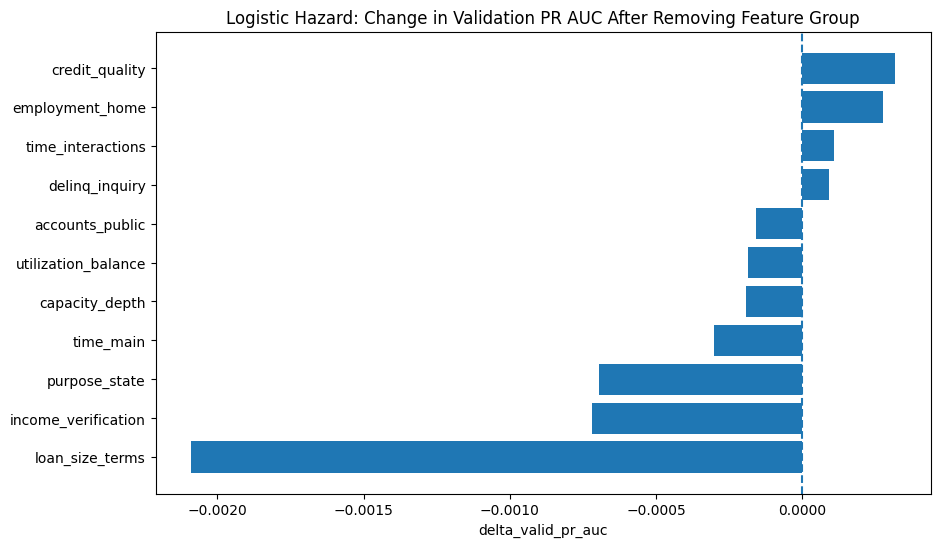

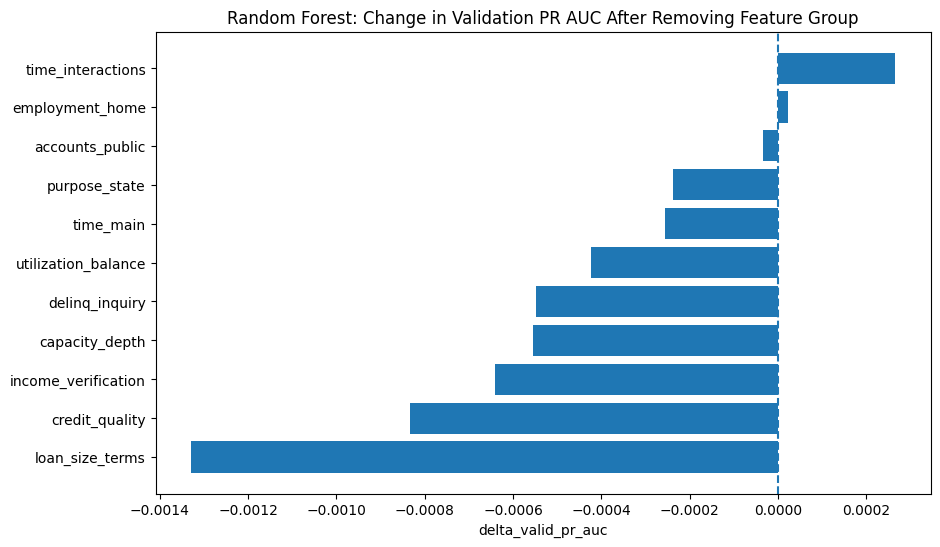

In [ ]:
plot_group_removal(
    grouped_logit_results,
    "delta_valid_pr_auc",
    "Logistic Hazard: Change in Validation PR AUC After Removing Feature Group"
)

plot_group_removal(
    grouped_rf_results,
    "delta_valid_pr_auc",
    "Random Forest: Change in Validation PR AUC After Removing Feature Group"
)

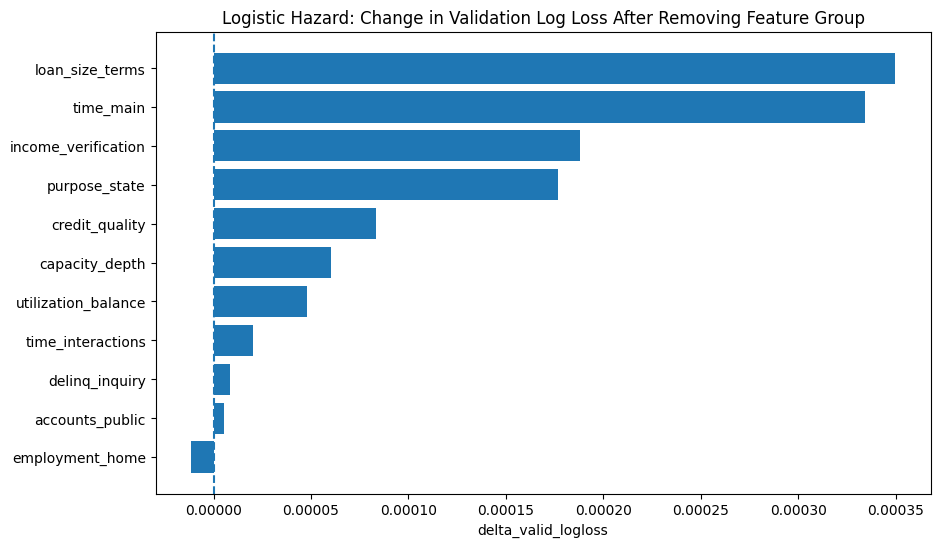

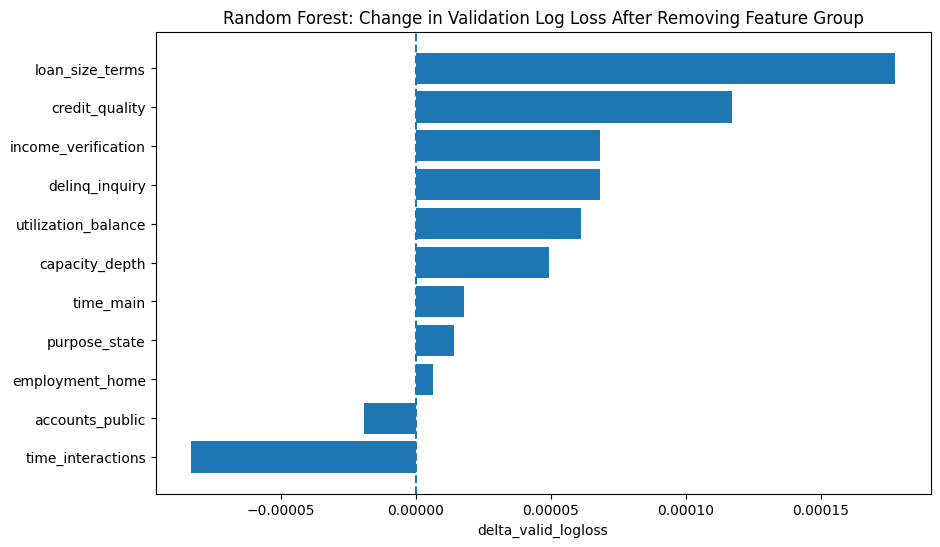

In [ ]:
plot_group_removal(
    grouped_logit_results,
    "delta_valid_logloss",
    "Logistic Hazard: Change in Validation Log Loss After Removing Feature Group"
)

plot_group_removal(
    grouped_rf_results,
    "delta_valid_logloss",
    "Random Forest: Change in Validation Log Loss After Removing Feature Group"
)

In [ ]:
baseline_logit_single, single_logit_results = run_group_removal_experiments(
    model_type="logit",
    feature_groups=single_feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

baseline_rf_single, single_rf_results = run_group_removal_experiments(
    model_type="rf",
    feature_groups=single_feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

single_logit_results.head(20)

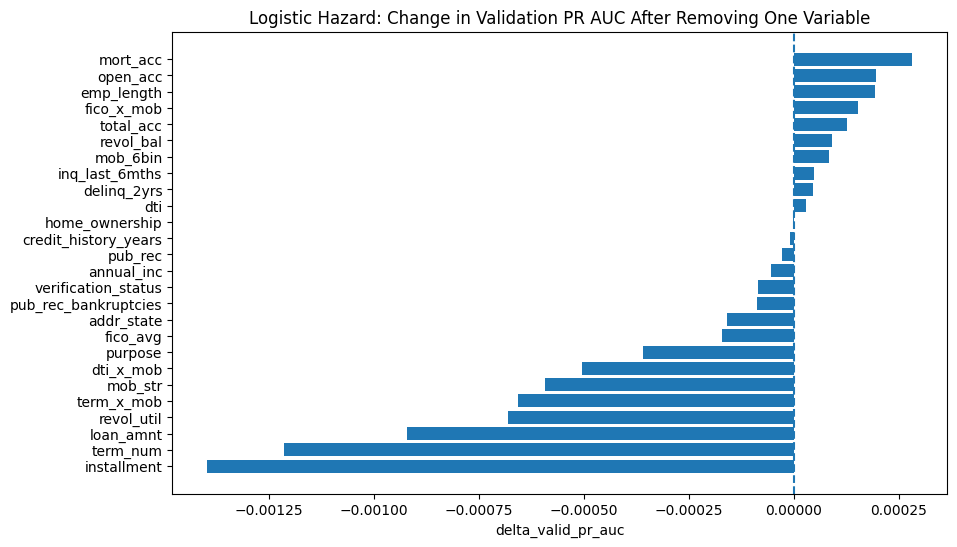

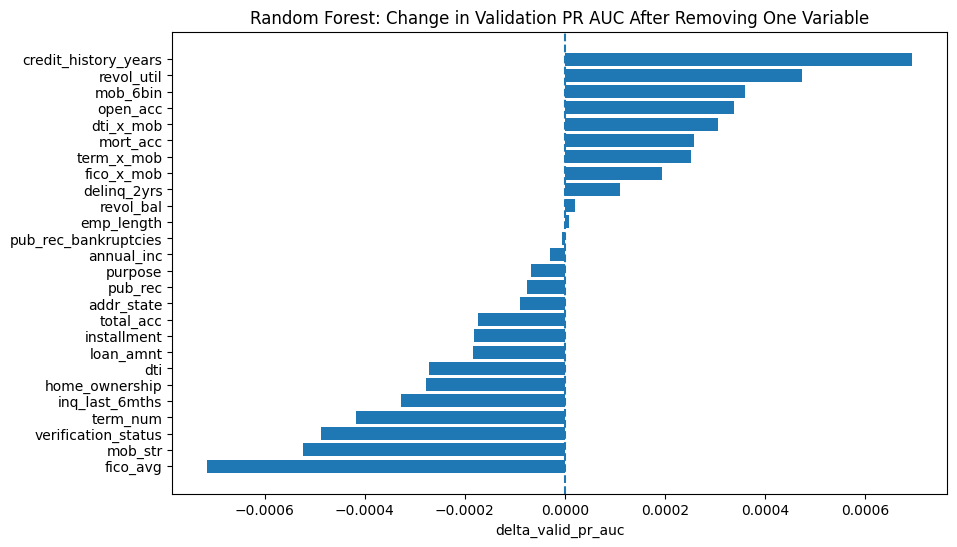

In [ ]:
plot_group_removal(
    single_logit_results,
    "delta_valid_pr_auc",
    "Logistic Hazard: Change in Validation PR AUC After Removing One Variable"
)

plot_group_removal(
    single_rf_results,
    "delta_valid_pr_auc",
    "Random Forest: Change in Validation PR AUC After Removing One Variable"
)

In [ ]:
def flag_removal_candidates(results_df, pr_tol=0.002, logloss_tol=0.005):
    out = results_df.copy()

    out["safe_to_remove"] = (
        (out["delta_valid_pr_auc"] >= -pr_tol) &
        (out["delta_valid_logloss"] <= logloss_tol)
    )

    return out.sort_values(
        ["safe_to_remove", "delta_valid_pr_auc", "delta_valid_logloss"],
        ascending=[False, False, True]
    )

flagged_logit = flag_removal_candidates(grouped_logit_results)
flagged_rf = flag_removal_candidates(grouped_rf_results)

flagged_logit[[
    "removed_group", "removed_vars",
    "delta_valid_pr_auc", "delta_valid_roc_auc",
    "delta_valid_logloss", "safe_to_remove"
]]

NameError: name 'grouped_logit_results' is not defined

In [ ]:
groups_to_remove_logit = flagged_logit.loc[
    flagged_logit["safe_to_remove"], "removed_group"
].tolist()

groups_to_remove_logit

['credit_quality',
 'employment_home',
 'time_interactions',
 'delinq_inquiry',
 'capacity_depth',
 'income_verification',
 'accounts_public',
 'time_main',
 'utilization_balance',
 'purpose_state',
 'loan_size_terms']

In [ ]:
groups_to_remove_logit = [
    "employment_home",
    "time_interactions",
    "capacity_depth",
]
remove_vars = []
for g in groups_to_remove_logit:
    remove_vars.extend(feature_groups[g])

remove_vars = sorted(set(remove_vars))

reduced_features_logit = [f for f in all_features if f not in remove_vars]

final_logit_reduced = fit_and_score_model(
    model_type="logit",
    features=reduced_features_logit,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

print("BASELINE LOGIT VALID:", baseline_logit["valid_metrics"])
print("REDUCED  LOGIT VALID:", final_logit_reduced["valid_metrics"])
print()
print("BASELINE LOGIT TEST :", baseline_logit["test_metrics"])
print("REDUCED  LOGIT TEST :", final_logit_reduced["test_metrics"])
print()
print("Reduced features:", reduced_features_logit)

BASELINE LOGIT VALID: {'roc_auc': 0.6707368973775432, 'pr_auc': 0.014084952061406895, 'brier': 0.00689730385618504, 'logloss': 0.04031133921256094, 'mean_pred': 0.006319581416688466, 'event_rate': 0.006962201922153251}
REDUCED  LOGIT VALID: {'roc_auc': 0.6720058194754052, 'pr_auc': 0.014458438286886949, 'brier': 0.006897121324603765, 'logloss': 0.04030573120398532, 'mean_pred': 0.006253191705819508, 'event_rate': 0.006962201922153251}

BASELINE LOGIT TEST : {'roc_auc': 0.6764559575734034, 'pr_auc': 0.008912978406677879, 'brier': 0.005109826723854781, 'logloss': 0.03395321397452347, 'mean_pred': 0.0058008378170974996, 'event_rate': 0.0045074236276504845}
REDUCED  LOGIT TEST : {'roc_auc': 0.6813756710792058, 'pr_auc': 0.009296471022492578, 'brier': 0.005057158232846492, 'logloss': 0.033086543858152684, 'mean_pred': 0.005806059314088518, 'event_rate': 0.0045074236276504845}

Reduced features: ['loan_amnt', 'term_num', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'o

In [ ]:
# Observed monthly event rate in the test panel
observed_monthly = (
    test_panel.groupby("month_on_book")["hazard_target"]
    .mean()
    .reset_index()
    .rename(columns={"hazard_target": "observed_monthly_hazard"})
    .sort_values("month_on_book")
)

# Convert observed monthly hazard to observed cumulative PD
observed_monthly["observed_survival"] = (
    1 - observed_monthly["observed_monthly_hazard"]
).cumprod()

observed_monthly["observed_cum_pd"] = 1 - observed_monthly["observed_survival"]

observed_monthly.head()

,month_on_book,observed_monthly_hazard,observed_survival,observed_cum_pd
0,1,0.001732,0.998268,0.001732
1,2,0.002604,0.995668,0.004332
2,3,0.003091,0.992590,0.007410
3,4,0.004853,0.987773,0.012227
4,5,0.004470,0.983358,0.016642


In [ ]:
def make_test_scored(panel_df, fitted_result, id_col="id", month_col="month_on_book"):
    features = fitted_result["features"]
    model = fitted_result["model"]

    scored = panel_df.copy()
    scored["pred_hazard"] = get_pred_proba(model, panel_df[features])

    scored = scored.sort_values([id_col, month_col]).copy()
    scored["survival_prob"] = scored.groupby(id_col)["pred_hazard"].transform(
        lambda x: (1 - x).cumprod()
    )
    scored["cum_pd"] = 1 - scored["survival_prob"]
    return scored

In [ ]:
baseline_scored = make_test_scored(test_panel, baseline_logit)
reduced_scored = make_test_scored(test_panel, final_logit_reduced)

baseline_curve = baseline_scored.groupby("month_on_book")["cum_pd"].mean().reset_index()
reduced_curve = reduced_scored.groupby("month_on_book")["cum_pd"].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(compare_curve["month_on_book"], compare_curve["observed_cum_pd"], label="Observed")
plt.plot(baseline_curve["month_on_book"], baseline_curve["cum_pd"], label="Baseline logit")
plt.plot(reduced_curve["month_on_book"], reduced_curve["cum_pd"], label="Reduced logit")
plt.xlabel("Month on book")
plt.ylabel("Average cumulative PD")
plt.title("Observed vs Baseline vs Reduced Logistic Hazard Model")
plt.legend()
plt.show()

NameError: name 'test_panel' is not defined

In [ ]:
logit_perm = permutation_importance(
    baseline_logit["model"],
    X_valid_full[baseline_logit["features"]],
    y_valid,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_logit_df = pd.DataFrame({
    "feature": baseline_logit["features"],
    "importance_mean": logit_perm.importances_mean,
    "importance_std": logit_perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_logit_df.head(20)

In [ ]:
plt.figure(figsize=(10, 6))
plot_df = perm_logit_df.sort_values("importance_mean", ascending=True).tail(20)
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation importance (Validation PR AUC decrease)")
plt.title("Logistic Hazard Permutation Importance")
plt.show()

NameError: name 'perm_logit_df' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
rf_perm = permutation_importance(
    baseline_rf["model"],
    X_valid_full[baseline_rf["features"]],
    y_valid,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_rf_df = pd.DataFrame({
    "feature": baseline_rf["features"],
    "importance_mean": rf_perm.importances_mean,
    "importance_std": rf_perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_rf_df.head(20)

In [ ]:
plt.figure(figsize=(10, 6))
plot_df = perm_rf_df.sort_values("importance_mean", ascending=True).tail(20)
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation importance (Validation PR AUC decrease)")
plt.title("Random Forest Permutation Importance")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
numeric_df = train_panel[all_numeric_features].copy()

# simple median fill for VIF calculation
numeric_df = numeric_df.fillna(numeric_df.median(numeric_only=True))

X_num = sm.add_constant(numeric_df)

vif_df = pd.DataFrame({
    "feature": X_num.columns,
    "VIF": [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

In [ ]:
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [ ]:
def backward_elimination_by_pr_auc(
    model_type,
    start_features,
    X_train_full, y_train,
    X_valid_full, y_valid,
    X_test_full, y_test,
    numeric_pool,
    categorical_pool,
    tolerance=0.002,
    random_state=42
):
    current_features = start_features.copy()
    history = []

    while True:
        baseline = fit_and_score_model(
            model_type=model_type,
            features=current_features,
            X_train_full=X_train_full, y_train=y_train,
            X_valid_full=X_valid_full, y_valid=y_valid,
            X_test_full=X_test_full, y_test=y_test,
            numeric_pool=numeric_pool,
            categorical_pool=categorical_pool,
            random_state=random_state
        )

        candidates = []
        for f in current_features:
            reduced = [x for x in current_features if x != f]

            result = fit_and_score_model(
                model_type=model_type,
                features=reduced,
                X_train_full=X_train_full, y_train=y_train,
                X_valid_full=X_valid_full, y_valid=y_valid,
                X_test_full=X_test_full, y_test=y_test,
                numeric_pool=numeric_pool,
                categorical_pool=categorical_pool,
                random_state=random_state
            )

            candidates.append({
                "removed_feature": f,
                "delta_valid_pr_auc": result["valid_metrics"]["pr_auc"] - baseline["valid_metrics"]["pr_auc"],
                "delta_valid_roc_auc": result["valid_metrics"]["roc_auc"] - baseline["valid_metrics"]["roc_auc"],
                "delta_valid_logloss": result["valid_metrics"]["logloss"] - baseline["valid_metrics"]["logloss"],
                "result": result,
            })

        cand_df = pd.DataFrame(candidates).sort_values(
            ["delta_valid_pr_auc", "delta_valid_roc_auc"],
            ascending=[False, False]
        ).reset_index(drop=True)

        best = cand_df.iloc[0]

        if best["delta_valid_pr_auc"] >= -tolerance:
            current_features.remove(best["removed_feature"])
            history.append({
                "removed_feature": best["removed_feature"],
                "delta_valid_pr_auc": best["delta_valid_pr_auc"],
                "delta_valid_roc_auc": best["delta_valid_roc_auc"],
                "delta_valid_logloss": best["delta_valid_logloss"],
                "n_features_remaining": len(current_features),
            })
        else:
            break

    final_result = fit_and_score_model(
        model_type=model_type,
        features=current_features,
        X_train_full=X_train_full, y_train=y_train,
        X_valid_full=X_valid_full, y_valid=y_valid,
        X_test_full=X_test_full, y_test=y_test,
        numeric_pool=numeric_pool,
        categorical_pool=categorical_pool,
        random_state=random_state
    )

    history_df = pd.DataFrame(history)
    return current_features, final_result, history_df

In [ ]:
reduced_features_auto, reduced_result_auto, reduction_history = backward_elimination_by_pr_auc(
    model_type="logit",
    start_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
    tolerance=0.002
)

print("Final reduced features:", reduced_features_auto)
print()
print("Reduced VALID metrics:", reduced_result_auto["valid_metrics"])
print("Reduced TEST metrics :", reduced_result_auto["test_metrics"])

In [ ]:
if len(reduction_history) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(range(1, len(reduction_history) + 1), reduction_history["delta_valid_pr_auc"])
    plt.axhline(0, linestyle="--")
    plt.xlabel("Removal step")
    plt.ylabel("Delta validation PR AUC")
    plt.title("Backward Elimination Path")
    plt.show()

reduction_history